In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import data 

In [2]:
df= pd.read_csv('../datasets/general_election_1970to2024.csv')
df.head()

,_id,Year,Constituency,NA,Province,District,Division,Party,Candidate Name,Regions 11,Regions 12,Regions 5,Registered Voters,Rejected Votes,Six Parties,Turnout N,Zones 20,Votes
0,1,1970,NA-1 - Peshawar,NA-1,KPK,Peshawar,Peshawar,JI,Hussain Ahmad Qazi,Peshawar Valley,Peshawar Valley,KPK,NaN,NaN,Religious Parties,NaN,Zone-3 (Peshawar Valley) Peshawar & Mardan Div...,2475.0
1,2,1970,NA-1 - Peshawar,NA-1,KPK,Peshawar,Peshawar,JUI-W.P,Molana Abdul Qayoom Popalzai,Peshawar Valley,Peshawar Valley,KPK,NaN,NaN,Religious Parties,NaN,Zone-3 (Peshawar Valley) Peshawar & Mardan Div...,13248.0
2,3,1970,NA-1 - Peshawar,NA-1,KPK,Peshawar,Peshawar,NAP-W,Arbab Sikandar Khan,Peshawar Valley,Peshawar Valley,KPK,NaN,NaN,Province Parties,NaN,Zone-3 (Peshawar Valley) Peshawar & Mardan Div...,21622.0
3,4,1970,NA-1 - Peshawar,NA-1,KPK,Peshawar,Peshawar,PML,Alfred Peter,Peshawar Valley,Peshawar Valley,KPK,NaN,NaN,Other Parties,NaN,Zone-3 (Peshawar Valley) Peshawar & Mardan Div...,2499.0
4,5,1970,NA-1 - Peshawar,NA-1,KPK,Peshawar,Peshawar,PML-Q,Khan Abdul Qayoom Khan,Peshawar Valley,Peshawar Valley,KPK,148708.0,1388.0,PML (s)/IJI/PNA,62.15402,Zone-3 (Peshawar Valley) Peshawar & Mardan Div...,27215.0


In [3]:
## data rows and cols

df.shape

(24585, 18)

In [4]:
## data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24585 entries, 0 to 24584
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   _id                24585 non-null  int64  
 1   Year               24585 non-null  int64  
 2   Constituency       24585 non-null  object 
 3   NA                 24585 non-null  object 
 4   Province           24551 non-null  object 
 5   District           24585 non-null  object 
 6   Division           24585 non-null  object 
 7   Party              24583 non-null  object 
 8   Candidate Name     21231 non-null  object 
 9   Regions 11         24584 non-null  object 
 10  Regions 12         24585 non-null  object 
 11  Regions 5          24584 non-null  object 
 12  Registered Voters  2805 non-null   float64
 13  Rejected Votes     2631 non-null   float64
 14  Six Parties        24545 non-null  object 
 15  Turnout N          2627 non-null   float64
 16  Zones 20           245

In [5]:
#check null values

null_values=df.isnull().sum()

print(null_values[null_values > 0])

Province                34
Party                    2
Candidate Name        3354
Regions 11               1
Regions 5                1
Registered Voters    21780
Rejected Votes       21954
Six Parties             40
Turnout N            21958
Votes                  193
dtype: int64


In [6]:
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
df['Votes']=df['Votes'].fillna(0)

In [7]:
# Drop rows where 'Party' is missing, as we analyze party performance
df = df.dropna(subset=['Party'])

# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [8]:
df.isnull().sum()

_id                      0
Year                     0
Constituency             0
NA                       0
Province                34
District                 0
Division                 0
Party                    0
Candidate Name        3354
Regions 11               0
Regions 12               0
Regions 5                0
Registered Voters    21778
Rejected Votes       21952
Six Parties             38
Turnout N            21956
Zones 20                 0
Votes                    0
dtype: int64

In [9]:
# drop field witch are less than equal to 5%
df.dropna(subset=["Province","Six Parties"], inplace=True)

In [10]:
df.isnull().sum()

_id                      0
Year                     0
Constituency             0
NA                       0
Province                 0
District                 0
Division                 0
Party                    0
Candidate Name        3354
Regions 11               0
Regions 12               0
Regions 5                0
Registered Voters    21710
Rejected Votes       21884
Six Parties              0
Turnout N            21888
Zones 20                 0
Votes                    0
dtype: int64

In [11]:
# fill Null values with large missing data 

df["Registered Voters"] = df["Registered Voters"].fillna(df["Registered Voters"].median())
df["Rejected Votes"] = df["Rejected Votes"].fillna(df["Rejected Votes"].median())
df["Turnout N"] = df["Turnout N"].fillna(df["Turnout N"].median())
df["Candidate Name"] = df["Candidate Name"].fillna("Unknown")

In [12]:
df.isnull().sum()

_id                  0
Year                 0
Constituency         0
NA                   0
Province             0
District             0
Division             0
Party                0
Candidate Name       0
Regions 11           0
Regions 12           0
Regions 5            0
Registered Voters    0
Rejected Votes       0
Six Parties          0
Turnout N            0
Zones 20             0
Votes                0
dtype: int64

In [13]:
df.columns

Index(['_id', 'Year', 'Constituency', 'NA', 'Province', 'District', 'Division',
       'Party', 'Candidate Name', 'Regions 11', 'Regions 12', 'Regions 5',
       'Registered Voters', 'Rejected Votes', 'Six Parties', 'Turnout N',
       'Zones 20', 'Votes'],
      dtype='object')

<Axes: xlabel='Year', ylabel='count'>

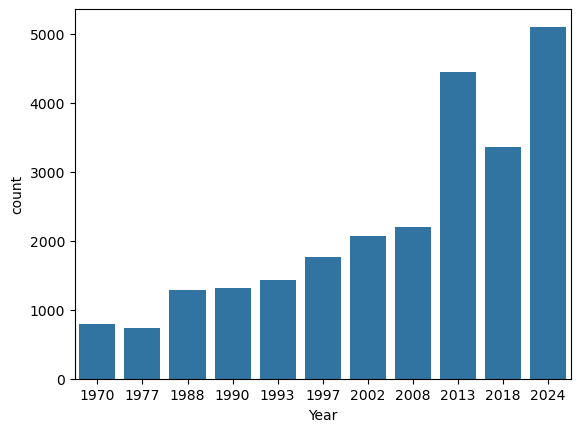

In [14]:
# data per years
sns.countplot(data=df, x='Year')

<Axes: xlabel='Year'>

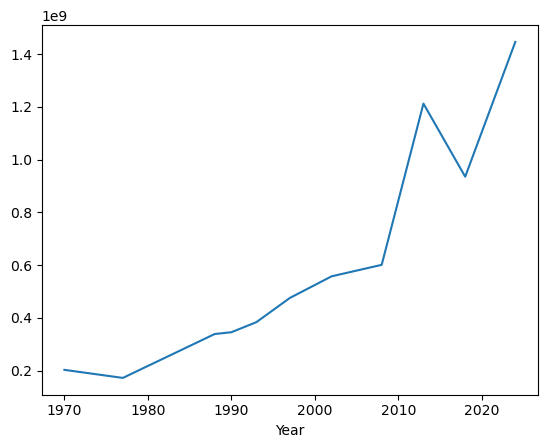

In [15]:
# number of voters per year 
df.groupby('Year')['Registered Voters'].sum().plot(kind='line')

In [16]:
df[df['Year'] == 2024]['Registered Voters'].sum()

np.float64(1446241286.0)

Text(0, 0.5, 'Total Votes (10s of Millions)')

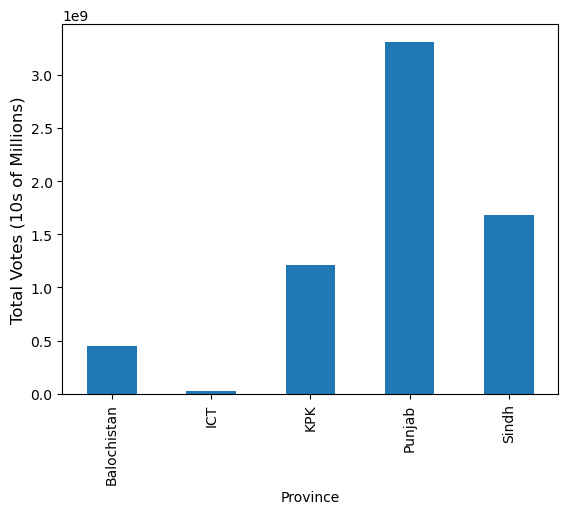

In [17]:
df.groupby('Province')['Registered Voters'].sum().plot(kind='bar')
plt.xlabel('Province')
plt.ylabel('Total Votes (10s of Millions)', fontsize=12)

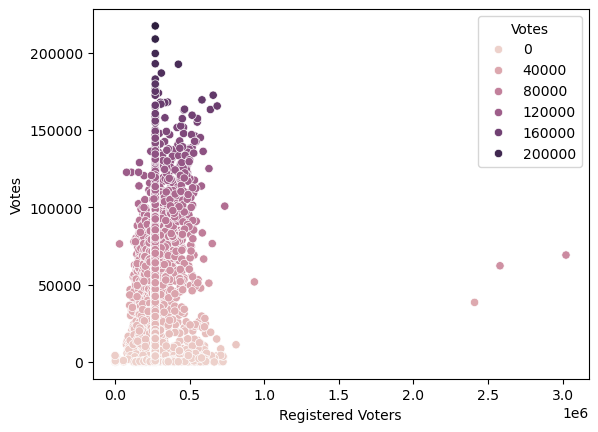

In [22]:
sns.scatterplot(data=df, x="Registered Voters", y="Votes", hue="Votes")
plt.show()

<Axes: xlabel='Votes', ylabel='Province'>

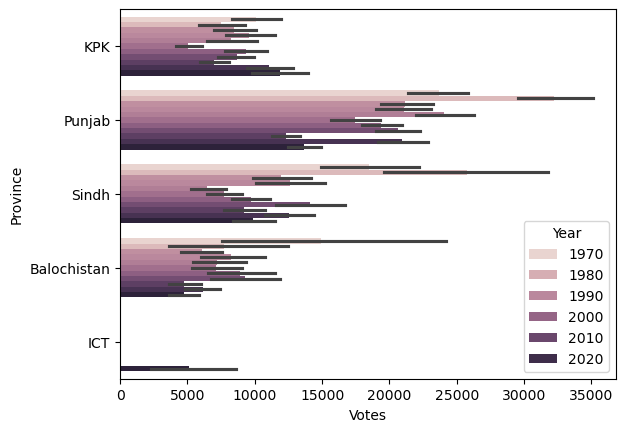

In [25]:
df.groupby("Party")["Votes"].sum().sort_values(ascending=False).head()

Party
PPP          76193621.0
PML-N        68916831.0
IND          33720715.0
PTI          25033291.0
IND (PTI)    18609625.0
Name: Votes, dtype: float64

In [28]:
#top 10 strong candidates overall years

df.sort_values(by="Votes", ascending=False)[
    ["Candidate Name", "Party", "Province", "Votes",'Year']
].head(10)

,Candidate Name,Party,Province,Votes,Year
24362,Muhammad Jamal Ahsan Khan,IND (PTI),Punjab,217427.0,2024
23883,Aniqa Mehdi,IND (PTI),Punjab,208943.0,2024
19712,Muhammad Ameer Sultan,IND (PTI),Punjab,199590.0,2024
21024,Omar Ayub Khan,IND (PTI),KPK,192948.0,2024
14205,Abdul Waseem,MQM,Sindh,192638.0,2013
10674,Sufyan Yousuf,MQM,Sindh,186933.0,2008
23886,Saira Tarar,PML-N,Punjab,183020.0,2024
24397,Umair Khan Niazi,IND (PTI),Punjab,179820.0,2024
20130,Muhammad Nawaz Sharif,PML-N,Punjab,179310.0,2024
19678,Waqas Akram,IND (PTI),Punjab,176586.0,2024


In [29]:
#corelation between registerd voters and actual votes

#If correlation > 0.7 → strong relationship


df[["Registered Voters", "Votes"]].corr()

,Registered Voters,Votes
Registered Voters,1.000000,0.132406
Votes,0.132406,1.000000


<Axes: xlabel='Year'>

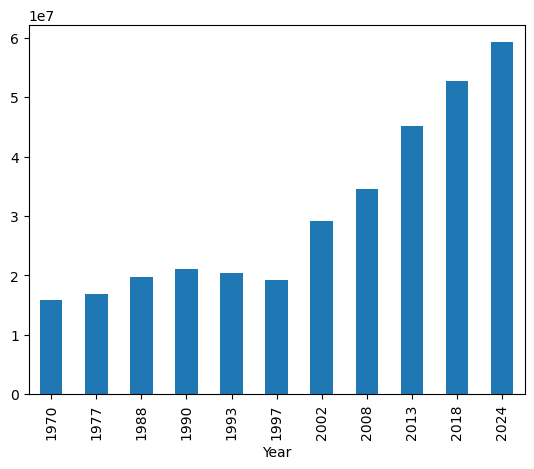

In [31]:
#actual vote cast per each province 

df.groupby("Year")["Votes"].sum().plot(kind='bar')

In [32]:
# top districts per votes
df.groupby("District")["Votes"].sum().sort_values(ascending=False).head(10)

District
Karachi City      17807885.0
Faisalabad        16083230.0
Lahore            15620591.0
Multan            10479683.0
Rawalpindi         9987354.0
Gujranwala         9816783.0
Sialkot            9225696.0
Sargodha           8847069.0
Rahim Yar Khan     8360429.0
Gujrat             7516821.0
Name: Votes, dtype: float64

In [35]:
df.groupby(["Province", "Party"])["Votes"].sum().sort_values(ascending=False).head(10)

Province  Party                     
Punjab    PML-N                         60719563.0
          PPP                           44514125.0
Sindh     PPP                           26335628.0
Punjab    IND                           21937693.0
          PTI                           17678379.0
          IND (PTI)                     13395395.0
          IJI                           11722817.0
Sindh     MQM                            8222738.0
Punjab    Pakistan Muslim League         7491997.0
          Pakistan Muslim League(QA)     6415150.0
Name: Votes, dtype: float64

In [39]:
# votes rejected in each province

df.groupby("Province")["Rejected Votes"].sum().sort_values(ascending=False)

Province
Punjab         35321929.0
Sindh          17608203.0
KPK            12499543.0
Balochistan     4761759.0
ICT              308053.0
Name: Rejected Votes, dtype: float64

In [48]:
df["Turnout %"] = (df["Votes"] / df["Registered Voters"]) * 100

In [45]:
# turnout per province

df.groupby("Province")["Turnout %"].mean().sort_values(ascending=False)

Province
KPK                 inf
Punjab         6.598865
Sindh          4.044231
Balochistan    2.443702
ICT            1.840942
Name: Turnout %, dtype: float64

In [47]:
#Top Constituencies with highest votes

df.groupby("Constituency")["Votes"].sum().sort_values(ascending=False).head(10)

Constituency
NA-3 - Peshawar             792795.0
NA-79 - Gujranwala          787848.0
NA-18 - Dera Ismail Khan    766340.0
NA-42 - Attock              739682.0
NA-60 - Chakwal             737606.0
NA-19 - Haripur             712534.0
NA-140 - Kasur              710257.0
NA-1 - Peshawar             705405.0
NA-256 - Karachi City       704943.0
NA-243 - Karachi City       690277.0
Name: Votes, dtype: float64

Text(0.5, 1.0, 'Votes Distribution')

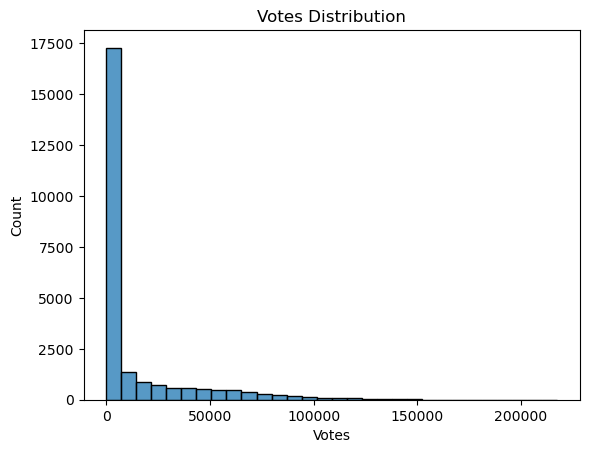

In [49]:
sns.histplot(df["Votes"], bins=30)
plt.title("Votes Distribution")